# Instalación del entorno

In [4]:
!pip install mne -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 62.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [6]:
import os
import sys
import numpy as np
import pandas as pd

# --- Configuración de entorno (Drive + repo) ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PATH_DRIVE = '/content/drive/MyDrive'
    REPO_NAME = 'BCI-MENTORIA-UNC'
    PATH_REPO = os.path.join(PATH_DRIVE, REPO_NAME)
    os.chdir(PATH_REPO)
    sys.path.append(PATH_REPO)
    print(f"-> Directorio de trabajo: {os.getcwd()}")
except ImportError:
    print("-> Entorno Local PC.")

import mne
mne.set_log_level('ERROR')
from src.eeg_datasets.preprocessed_dataset import PreprocessedDataset

def binarize_y(y):
    unique_classes = np.unique(y)
    assert len(unique_classes) == 2, "y debe tener exactamente dos clases distintas"
    class_to_bin = {unique_classes[0]: 0, unique_classes[1]: 1}
    bin_to_class = {v: k for k, v in class_to_bin.items()}
    y_bin = np.vectorize(class_to_bin.get)(y)
    return y_bin, bin_to_class

CHANNELS = ["C3", "Cz", "C4"]
SESSIONS = ["session_1"]
DATA_TO_LOAD = ["motor_imagery"]
SFREQ = 128
RANDOM_SEED = 45
K_FOLDS = 5

print(f"SESSIONS={SESSIONS}, DATA_TO_LOAD={DATA_TO_LOAD}, CHANNELS={CHANNELS}")

Mounted at /content/drive
-> Directorio de trabajo: /content/drive/MyDrive/BCI-MENTORIA-UNC
SESSIONS=['session_1'], DATA_TO_LOAD=['motor_imagery'], CHANNELS=['C3', 'Cz', 'C4']


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne
import os

# Importamos tu módulo personalizado de ingeniería de características
from src.eeg_datasets.preprocessed_dataset import PreprocessedDataset
from src.features_engineering.power_features import SignalProcessor

# Configuración estética de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]

# 📌 Nota introductoria — Cómo usar esta notebook (Fase 4: Stress Test)

Esta notebook contiene el análisis cruzado (cross-subject y cross-dataset) de los sujetos 43 (buen desempeño) y 45 (bajo desempeño), tanto para SVM como para EEGNet, además del análisis poblacional de generalización sobre los 60 sujetos.

No es necesario re-extraer features ni reentrenar modelos. Alcanza con ejecutar la celda de carga de checkpoints al inicio de esta sección para recuperar:

Los datasets Dreyer2023A y Cho2017 ya instanciados.
Las features de ambos datasets, ya extraídas.
Los resultados de cross-testing de SVM (sujetos 43/45) y EEGNet (sujetos 43/45).
Los datos poblacionales (df_final_svm, filtro de BCI Illiteracy) para el análisis agregado de 60 sujetos.

Lo que sí hay que volver a ejecutar:

- Las celdas de gráfico/tabla que quieras visualizar (rápidas, solo procesan datos ya cargados).
- Los groupby/correlaciones del análisis poblacional (Etapa 6 en adelante). No son costosos, se recalculan al instante a partir de datos ya cargados.

In [7]:
# ============================================================================
# CARGA COMPLETA DE CHECKPOINTS — Fase 4 (Stress Test)
# ============================================================================
import os, sys, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------------------
# ETAPA 0 — Entorno
# ----------------------------------------------------------------------------
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

PATH_REPO = '/content/drive/MyDrive/BCI-MENTORIA-UNC'
sys.path.append(PATH_REPO)
os.chdir(PATH_REPO)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]

import mne
mne.set_log_level('ERROR')
from src.eeg_datasets.preprocessed_dataset import PreprocessedDataset

def binarize_y(y):
    unique_classes = np.unique(y)
    class_to_bin = {unique_classes[0]: 0, unique_classes[1]: 1}
    bin_to_class = {v: k for k, v in class_to_bin.items()}
    return np.vectorize(class_to_bin.get)(y), bin_to_class

def binarizar_por_event_id(Y_labels, event_id):
    mapa = {event_id['left_hand']: 0, event_id['right_hand']: 1}
    return np.vectorize(mapa.get)(Y_labels)

CHANNELS = ["C3", "Cz", "C4"]
SESSIONS = ["session_1"]
DATA_TO_LOAD = ["motor_imagery"]
SFREQ = 128
RANDOM_SEED = 45
K_FOLDS = 5

print("✅ ETAPA 0 — Entorno listo")

# ----------------------------------------------------------------------------
# ETAPA 1 — Datasets (Dreyer2023A + Cho2017)
# ----------------------------------------------------------------------------
try:
    dataset_dreyer = PreprocessedDataset(db_name="Dreyer2023A", sessions=SESSIONS,
                                          subjects=None, data_to_load=DATA_TO_LOAD, channels=CHANNELS)
    dataset_cho = PreprocessedDataset(db_name="Cho2017", sessions=SESSIONS,
                                       subjects=None, data_to_load=DATA_TO_LOAD, channels=CHANNELS)
    lista_sujetos_cho = dataset_cho.get_subjects_list()
    print(f"✅ ETAPA 1 — Dreyer2023A: {len(dataset_dreyer.get_subjects_list())} sujetos | "
          f"Cho2017: {len(lista_sujetos_cho)} sujetos")
except Exception as e:
    print(f"⚠️ ETAPA 1 incompleta: {e}")

# ----------------------------------------------------------------------------
# ETAPA 2 — Features Dreyer2023A + modelo SVM
# ----------------------------------------------------------------------------
try:
    DIR_DATA = os.path.join(PATH_REPO, "data_procesada")
    df_check = pd.read_parquet(os.path.join(DIR_DATA, "features_largo_todos_sujetos.parquet"))
    df_features_wide = df_check.pivot_table(
        index=['subject_id', 'trial_idx', 'label'], columns='feature_col', values='valor'
    ).reset_index()

    with open(os.path.join(DIR_DATA, "features_finales_seleccionadas.json"), 'r') as f:
        features_finales = json.load(f)['features']

    lista_sujetos_dreyer = list(df_features_wide['subject_id'].unique())

    def cargar_modelo_svm(subject_id):
        ruta = os.path.join(PATH_REPO, "models", "SVM", f"subject_{subject_id}", "modelo_final_reentrenado.pkl")
        with open(ruta, 'rb') as f:
            return pickle.load(f)

    print(f"✅ ETAPA 2 — df_features_wide {df_features_wide.shape}, "
          f"{len(features_finales)} features, {len(lista_sujetos_dreyer)} sujetos")
except Exception as e:
    print(f"⚠️ ETAPA 2 incompleta: {e}")

# ----------------------------------------------------------------------------
# ETAPA 3 — Features Cho2017 (ya extraídas)
# ----------------------------------------------------------------------------
try:
    df_features_wide_cho = pd.read_parquet(
        os.path.join(PATH_REPO, "data_procesada", "features_wide_cho2017.parquet"))
    print(f"✅ ETAPA 3 — df_features_wide_cho {df_features_wide_cho.shape}")
except Exception as e:
    print(f"⚠️ ETAPA 3 incompleta: {e}")

# ----------------------------------------------------------------------------
# ETAPA 4 — Stress test SVM (sujetos 43/45 + población completa si existe)
# ----------------------------------------------------------------------------
try:
    df_cross_bueno = pd.read_csv(os.path.join(
        PATH_REPO, "models", "comparaciones", "stress_test_SVM_sujeto_bueno_43.csv"))
    # ⚠️ Bug de nombre: el archivo del sujeto "malo" (45) quedó guardado como "...malo_43.csv"
    df_cross_malo = pd.read_csv(os.path.join(
        PATH_REPO, "models", "comparaciones", "stress_test_SVM_sujeto_malo_43.csv"))
    print(f"✅ ETAPA 4a — df_cross_bueno (43) / df_cross_malo (45, nombre con bug '_43')")
except Exception as e:
    print(f"⚠️ ETAPA 4a incompleta: {e}")

try:
    df_cross_completo = pd.read_csv(os.path.join(
        PATH_REPO, "models", "comparaciones", "stress_test_SVM_completo.csv"))
    print(f"✅ ETAPA 4b — df_cross_completo (60 sujetos): {len(df_cross_completo)} cruces")
except Exception as e:
    print(f"⚠️ ETAPA 4b — stress test SVM completo (60 sujetos) no encontrado: {e}")
    print("   Si nunca se corrió, hay que relanzar el loop de 60 sujetos origen.")

# ----------------------------------------------------------------------------
# ETAPA 5 — Stress test EEGNet (sujetos 43/45)
# ----------------------------------------------------------------------------
try:
    import torch, torch.nn as nn
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    class EEGNet(nn.Module):
        def __init__(self, n_channels=3, n_times=256, F1=8, D=2, F2=16, dropout_rate=0.5):
            super().__init__()
            self.block1 = nn.Sequential(
                nn.Conv2d(1, F1, (1, 64), padding=(0, 32), bias=False), nn.BatchNorm2d(F1),
                nn.Conv2d(F1, F1 * D, (n_channels, 1), groups=F1, bias=False),
                nn.BatchNorm2d(F1 * D), nn.ELU(), nn.AvgPool2d((1, 4)), nn.Dropout(dropout_rate))
            self.block2 = nn.Sequential(
                nn.Conv2d(F1 * D, F1 * D, (1, 16), padding=(0, 8), groups=F1 * D, bias=False),
                nn.Conv2d(F1 * D, F2, (1, 1), bias=False),
                nn.BatchNorm2d(F2), nn.ELU(), nn.AvgPool2d((1, 8)), nn.Dropout(dropout_rate))
            with torch.no_grad():
                dummy = torch.zeros(1, 1, n_channels, n_times)
                flat_size = self.block2(self.block1(dummy)).view(1, -1).shape[1]
            self.classifier = nn.Linear(flat_size, 1)
        def forward(self, x):
            x = self.block1(x); x = self.block2(x)
            return self.classifier(x.view(x.size(0), -1))

    DIR_EEGNET_DEMO = os.path.join(PATH_REPO, "models", "EEGNet", "stress_test")

    def cargar_eegnet(sujeto_id):
        checkpoint = torch.load(os.path.join(DIR_EEGNET_DEMO, f"eegnet_subject_{sujeto_id}.pt"), weights_only=False)
        model = EEGNet(n_channels=checkpoint['n_channels'], n_times=checkpoint['n_times']).to(device)
        model.load_state_dict(checkpoint['state_dict'])
        model.eval()
        return model, checkpoint['mean_tr'], checkpoint['std_tr']

    def predecir_eegnet(model, mean_tr, std_tr, X_eeg_destino):
        X_norm = (X_eeg_destino - mean_tr) / (std_tr + 1e-8)
        X_t = torch.tensor(X_norm, dtype=torch.float32).unsqueeze(1).to(device)
        with torch.no_grad():
            probs = torch.sigmoid(model(X_t)).cpu().numpy().flatten()
        return (probs > 0.5).astype(int), probs

    df_eegnet_cross = pd.read_csv(os.path.join(
        PATH_REPO, "models", "comparaciones", "stress_test_EEGNet_43_45.csv"))
    print(f"✅ ETAPA 5 — df_eegnet_cross: {len(df_eegnet_cross)} cruces (sujetos 43/45)")
except Exception as e:
    print(f"⚠️ ETAPA 5 incompleta: {e}")

# ----------------------------------------------------------------------------
# ETAPA 6 — Análisis poblacional SVM (BCI Illiteracy + correlación)
# ----------------------------------------------------------------------------
try:
    df_final_svm = pd.read_csv(os.path.join(PATH_REPO, "models", "SVM", "df_final_SVM.csv"))
    df_umbral_sujetos = pd.read_csv(os.path.join(
        PATH_REPO, "models", "bci_illiteracy", "umbral_aptitud_por_sujeto.csv"))
    print(f"✅ ETAPA 6 — df_final_svm ({len(df_final_svm)}) / df_umbral_sujetos ({len(df_umbral_sujetos)})")
except Exception as e:
    print(f"⚠️ ETAPA 6 incompleta: {e}")

print("\n🏁 Carga de checkpoints (Fase 4) finalizada.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ ETAPA 0 — Entorno listo
✅ ETAPA 1 — Dreyer2023A: 60 sujetos | Cho2017: 52 sujetos
✅ ETAPA 2 — df_features_wide (19032, 78), 11 features, 60 sujetos
✅ ETAPA 3 — df_features_wide_cho (10520, 78)
✅ ETAPA 4a — df_cross_bueno (43) / df_cross_malo (45, nombre con bug '_43')
✅ ETAPA 4b — df_cross_completo (60 sujetos): 6660 cruces
✅ ETAPA 5 — df_eegnet_cross: 222 cruces (sujetos 43/45)
✅ ETAPA 6 — df_final_svm (60) / df_umbral_sujetos (60)

🏁 Carga de checkpoints (Fase 4) finalizada.


## El Test de Robustez (Stress Test)

Un Test de Robustez (Stress Test) evalúa si un modelo sigue funcionando bien cuando se lo aleja de las condiciones "cómodas" bajo las que fue entrenado y validado; es decir, mide qué tan frágil o sólido es el modelo ante cambios que, en un escenario real de uso, son inevitables.

Antes de diseñar todo el stress test, necesitamos confirmar que Cho2017 es utilizable con el mismo framework y que su estructura es compatible con lo que ya construyó.

# MODELO ML : SVM

## Importante

Las fases anteriores evaluaron el rendimiento de los modelos bajo un supuesto favorable pero poco realista: que el modelo se entrena y se testea con datos del mismo sujeto. Esta configuración, si bien necesaria para establecer una línea base y filtrar casos de BCI Illiteracy, no responde a una pregunta clave para cualquier sistema BCI con aspiración de uso práctico: ¿el modelo entrenado con la señal de una persona sirve para clasificar la señal de otra persona que nunca vio durante el entrenamiento?

Esta fase introduce dos escenarios de evaluación deliberadamente más exigentes que los anteriores:

1. **Cross-sujeto (intra-dataset)**: modelos entrenados con la señal completa de un sujeto particular son testeados contra el resto de la población de Dreyer2023A, sin que ningún dato del sujeto de testeo participe en el entrenamiento.
2. **Generalización cross-dataset**: los mismos modelos son testeados contra sujetos del dataset Cho2017, introduciendo además una fuente adicional de variación — el equipo de adquisición y el protocolo experimental — que no está presente en el escenario anterior.

Para el modelo de Machine Learning (SVM Lineal), el análisis se realiza sobre la **totalidad de los 60 sujetos** de Dreyer2023A como origen, cada uno testeado contra los 59 sujetos restantes de la misma base y contra los sujetos de Cho2017 — cumpliendo así el alcance completo solicitado. Para el modelo de Deep Learning (EEGNet), dado el costo computacional sustancialmente mayor de la inferencia sobre arquitecturas neuronales entrenadas individualmente por sujeto, se optó por un **subconjunto reducido y deliberadamente contrastante** de sujetos origen: aquellos con mayor y menor rendimiento individual, identificados a partir del filtro de BCI Illiteracy en fases previas. Esta decisión de alcance diferenciado se documenta y justifica explícitamente por razones de viabilidad temporal, y permite igualmente formular una pregunta con valor narrativo concreto para el análisis final: ¿el modelo entrenado con un sujeto de alto desempeño generaliza mejor a la población que el entrenado con un sujeto de bajo desempeño?

Se espera, y así lo indica la literatura del área, que el rendimiento caiga de forma sistemática respecto al escenario intra-sujeto. Esta caída no debe interpretarse como una falla del pipeline, sino como el reflejo esperado de fuentes de variabilidad biológica y técnica genuinas: diferencias anatómicas entre sujetos, estrategias cognitivas individuales para la imaginación motora, la propia heterogeneidad que define al fenómeno de BCI Illiteracy, y — en el caso cross-dataset — diferencias sistemáticas de adquisición entre equipos y protocolos. El objetivo de esta fase, entonces, no es maximizar el accuracy, sino cuantificar y explicar esa caída de rendimiento.

### Paso 1: Cargar Cho2017 y verificar compatibilidad básica

- Carga de ambos datasets

In [ ]:
dataset_dreyer = PreprocessedDataset(
    db_name="Dreyer2023A",
    sessions=SESSIONS,
    subjects=None,
    data_to_load=DATA_TO_LOAD,
    channels=CHANNELS,
)

dataset_cho = PreprocessedDataset(
    db_name="Cho2017",
    sessions=SESSIONS,
    subjects=None,
    data_to_load=DATA_TO_LOAD,
    channels=CHANNELS,
)

print("Dreyer2023A sujetos:", len(dataset_dreyer.get_subjects_list()))
print("Cho2017 sujetos:", len(dataset_cho.get_subjects_list()))

Dreyer2023A sujetos: 60
Cho2017 sujetos: 52


- Verificación de compatibilidad entre ambos datasets

In [ ]:
X_test_dreyer, Y_test_dreyer, _ = dataset_dreyer.flatten_pool_data(subject_ids=[dataset_dreyer.get_subjects_list()[0]])
X_test_cho, Y_test_cho, _ = dataset_cho.flatten_pool_data(subject_ids=[dataset_cho.get_subjects_list()[0]])

print(f"Shape Dreyer2023A: {X_test_dreyer.shape}")
print(f"Shape Cho2017: {X_test_cho.shape}")
print(f"event_id Dreyer: {dataset_dreyer.event_id}")
print(f"event_id Cho2017: {dataset_cho.event_id}")

Shape Dreyer2023A: (320, 3, 256)
Shape Cho2017: (200, 3, 256)
event_id Dreyer: {'left_hand': 769, 'right_hand': 770}
event_id Cho2017: {'left_hand': 1, 'right_hand': 2}


Ambas bases difieren en la cantidad de sujetos; también corresponde a realizar una binarización de la variable objetivo. Se evidencia que la cantidad de ensayos por sujetos también difiere.

In [ ]:
def binarizar_por_event_id(Y_labels, event_id):
    mapa = {event_id['left_hand']: 0, event_id['right_hand']: 1}
    return np.vectorize(mapa.get)(Y_labels)

## Testear los modelos

### Paso 1: Extraer features de Cho2017 para TODOS sus sujetos (52, no 60)

In [ ]:
!pip install mne_features antropy statsmodels -q

In [ ]:
import numpy as np
import pandas as pd
import math
from scipy.stats import kurtosis, skew
from scipy.signal import welch, coherence, hilbert

def feature_total_power(X):
    assert X.ndim == 3
    return np.mean(np.square(X), axis=-1)

def feature_band_power(X, sfreq=128, fbands=[(4,8), (8,12), (12,16), (16,20), (20,24), (28,30)]):
    assert X.ndim == 3
    n_ensayos, n_canales, n_tiempos = X.shape
    n_bandas = len(fbands)
    frecuencias, psd = welch(X, fs=sfreq, axis=-1, nperseg=int(sfreq))
    X_features = np.zeros((n_ensayos, n_canales * n_bandas))
    for idx_banda, (f_min, f_max) in enumerate(fbands):
        indices_banda = (frecuencias >= f_min) & (frecuencias <= f_max)
        potencia_banda = np.mean(psd[:, :, indices_banda], axis=-1)
        for idx_canal in range(n_canales):
            columna_idx = idx_canal * n_bandas + idx_banda
            X_features[:, columna_idx] = potencia_banda[:, idx_canal]
    return X_features

def feature_kurtosis(X):
    assert X.ndim == 3
    return kurtosis(X, axis=-1)

def feature_skewness(X):
    assert X.ndim == 3
    return skew(X, axis=-1)

def feature_katz_fractal_dim(X):
    assert X.ndim == 3
    n_ensayos, n_canales, n_tiempos = X.shape
    out = np.zeros((n_ensayos, n_canales))
    for e in range(n_ensayos):
        for c in range(n_canales):
            senal = X[e, c, :]
            L = np.sum(np.abs(np.diff(senal)))
            d = np.max(np.abs(senal - senal[0]))
            katz = np.log10(n_tiempos) / (np.log10(n_tiempos) + np.log10(d / (L + 1e-8)) + 1e-8)
            out[e, c] = katz
    return out

def feature_autoregressive_coefs(X, order=4):
    assert X.ndim == 3
    n_ensayos, n_canales, n_tiempos = X.shape
    out = np.zeros((n_ensayos, n_canales * order))
    for e in range(n_ensayos):
        for c in range(n_canales):
            senal = X[e, c, :]
            r = np.correlate(senal, senal, mode='full')[n_tiempos-1 : n_tiempos + order + 1]
            r /= r[0]
            R = np.zeros((order, order))
            for i in range(order):
                R[i, :] = r[abs(np.arange(order) - i)]
            b = r[1:order+1]
            try:
                ar_coefs = np.linalg.solve(R, b)
            except np.linalg.LinAlgError:
                ar_coefs = np.zeros(order)
            out[e, c*order : c*order + order] = ar_coefs
    return out

def feature_permutation_entropy(X, order=3, delay=1):
    assert X.ndim == 3
    n_ensayos, n_canales, n_tiempos = X.shape
    out = np.zeros((n_ensayos, n_canales))
    for e in range(n_ensayos):
        for c in range(n_canales):
            x = X[e, c, :]
            n_words = n_tiempos - (order - 1) * delay
            words = np.zeros((n_words, order))
            for i in range(order):
                words[:, i] = x[i * delay : i * delay + n_words]
            orders = np.argsort(words, axis=1)
            _, counts = np.unique(orders, axis=0, return_counts=True)
            probs = counts / counts.sum()
            pe = -np.sum(probs * np.log2(probs))
            out[e, c] = pe / np.log2(math.factorial(order))
    return out

def feature_cross_correlation(X):
    assert X.ndim == 3
    n_ensayos, _, _ = X.shape
    out = np.zeros((n_ensayos, 3))
    pares = [(0, 1), (2, 1), (0, 2)]
    for e in range(n_ensayos):
        for idx_par, (chA, chB) in enumerate(pares):
            corr = np.corrcoef(X[e, chA, :], X[e, chB, :])[0, 1]
            out[e, idx_par] = 0.0 if np.isnan(corr) else corr
    return out

def feature_magnitude_squared_coherence(X, sfreq=128, fbands=[(8, 12), (12, 30)]):
    assert X.ndim == 3
    n_ensayos, _, _ = X.shape
    n_bandas = len(fbands)
    out = np.zeros((n_ensayos, 3 * n_bandas))
    pares = [(0, 1), (2, 1), (0, 2)]
    for e in range(n_ensayos):
        col_idx = 0
        for chA, chB in pares:
            f, msc = coherence(X[e, chA, :], X[e, chB, :], fs=sfreq, nperseg=int(sfreq))
            for f_min, f_max in fbands:
                idx_b = (f >= f_min) & (f <= f_max)
                out[e, col_idx] = np.mean(msc[idx_b]) if np.any(idx_b) else 0.0
                col_idx += 1
    return out

def feature_phase_locking_value(X):
    assert X.ndim == 3
    n_ensayos, _, _ = X.shape
    out = np.zeros((n_ensayos, 3))
    pares = [(0, 1), (2, 1), (0, 2)]
    for e in range(n_ensayos):
        for idx_par, (chA, chB) in enumerate(pares):
            faseA = np.angle(hilbert(X[e, chA, :]))
            faseB = np.angle(hilbert(X[e, chB, :]))
            out[e, idx_par] = np.abs(np.mean(np.exp(1j * (faseA - faseB))))
    return out

pipeline_config = {
    "potencia_total":      {"active": True, "method": feature_total_power, "params": {}},
    "bandas_frecuencia":   {"active": True, "method": feature_band_power, "params": {"sfreq": 128, "fbands": [(4,8),(8,12),(12,16),(16,20),(20,24),(28,30)]}},
    "kurtosis":            {"active": True, "method": feature_kurtosis, "params": {}},
    "skewness":            {"active": True, "method": feature_skewness, "params": {}},
    "katz_fractal":        {"active": True, "method": feature_katz_fractal_dim, "params": {}},
    "coeficientes_ar":     {"active": True, "method": feature_autoregressive_coefs, "params": {"order": 10}},
    "entropia_perm":       {"active": True, "method": feature_permutation_entropy, "params": {"order": 3}},
    "correlacion_cruzada": {"active": True, "method": feature_cross_correlation, "params": {}},
    "coherencia_msc":      {"active": True, "method": feature_magnitude_squared_coherence, "params": {"sfreq": 128, "fbands": [(8,12),(12,30)]}},
    "plv_fase":            {"active": True, "method": feature_phase_locking_value, "params": {}},
}

### Paso 2: Extraer features para todos los sujetos de Cho2017, con checkpoint

In [ ]:
DIR_SALIDA_CHO = os.path.join(PATH_REPO, "data_procesada", "features_por_sujeto_cho2017")
os.makedirs(DIR_SALIDA_CHO, exist_ok=True)

registros_features_cho = []

for sujeto in lista_sujetos_cho:
    ruta_sujeto = os.path.join(DIR_SALIDA_CHO, f"sujeto_{sujeto}.parquet")

    if os.path.exists(ruta_sujeto):
        df_sujeto_largo = pd.read_parquet(ruta_sujeto)
        registros_features_cho.append(df_sujeto_largo)
        print(f"↺ [{sujeto}] -> ya existía, cargado desde checkpoint")
        continue

    try:
        X_eeg, Y_labels, metadata = dataset_cho.flatten_pool_data(subject_ids=[sujeto])
        Y_labels_bin = binarizar_por_event_id(Y_labels, dataset_cho.event_id)  # binarización robusta, semántica

        features_del_sujeto = []
        columnas_sujeto = []

        for nombre_feat, config in pipeline_config.items():
            if not config["active"]:
                continue
            func = config["method"]
            params = config["params"]
            res_feat = func(X_eeg, **params)
            if res_feat.ndim == 1:
                res_feat = res_feat[:, np.newaxis]
            features_del_sujeto.append(res_feat)

            if nombre_feat in ["potencia_total", "kurtosis", "skewness", "katz_fractal", "entropia_perm"]:
                columnas_sujeto += [f"{nombre_feat}_{ch}" for ch in CHANNELS]
            elif nombre_feat == "coeficientes_ar":
                order_set = params.get("order", 4)
                columnas_sujeto += [f"AR_coef{i+1}_{ch}" for ch in CHANNELS for i in range(order_set)]
            elif nombre_feat in ["correlacion_cruzada", "plv_fase"]:
                columnas_sujeto += [f"{nombre_feat}_{par}" for par in ["C3-Cz","C4-Cz","C3-C4"]]
            elif nombre_feat in ["bandas_frecuencia", "coherencia_msc"]:
                fbands_list = params.get("fbands", [(8,12),(12,30)])
                n_bandas = len(fbands_list)
                if nombre_feat == "coherencia_msc":
                    columnas_sujeto += [f"coherencia_band_{b+1}_{par}" for par in ["C3-Cz","C4-Cz","C3-C4"] for b in range(n_bandas)]
                else:
                    columnas_sujeto += [f"power_band_{b+1}_{ch}" for ch in CHANNELS for b in range(n_bandas)]

        X_combinado = np.hstack(features_del_sujeto)
        df_sujeto = pd.DataFrame(X_combinado, columns=columnas_sujeto)
        df_sujeto['subject_id'] = sujeto
        df_sujeto['trial_idx'] = np.arange(len(df_sujeto))
        df_sujeto['label'] = Y_labels_bin

        df_sujeto_largo = df_sujeto.melt(id_vars=['subject_id','trial_idx','label'], var_name='feature_col', value_name='valor')
        df_sujeto_largo.to_parquet(ruta_sujeto, index=False)

        registros_features_cho.append(df_sujeto_largo)
        print(f"✔ [{sujeto}] -> {X_combinado.shape[1]} columnas procesadas y guardadas")

    except Exception as e:
        print(f"✗ [{sujeto}] -> FALLÓ: {e}")
        continue

df_features_largo_cho = pd.concat(registros_features_cho, ignore_index=True)
print(f"\n[COMPLETADO] {df_features_largo_cho['subject_id'].nunique()} sujetos procesados.")

# --- Pivotear a formato ancho, igual que hiciste con Dreyer2023A ---
df_features_wide_cho = df_features_largo_cho.pivot_table(
    index=['subject_id', 'trial_idx', 'label'],
    columns='feature_col',
    values='valor'
).reset_index()

ruta_wide_cho = os.path.join(PATH_REPO, "data_procesada", "features_wide_cho2017.parquet")
df_features_wide_cho.to_parquet(ruta_wide_cho, index=False)
print(f"df_features_wide_cho: {df_features_wide_cho.shape}")

✔ [1] -> 75 columnas procesadas y guardadas
✔ [2] -> 75 columnas procesadas y guardadas
✔ [3] -> 75 columnas procesadas y guardadas
✔ [4] -> 75 columnas procesadas y guardadas
✔ [5] -> 75 columnas procesadas y guardadas
✔ [6] -> 75 columnas procesadas y guardadas
✔ [7] -> 75 columnas procesadas y guardadas
✔ [8] -> 75 columnas procesadas y guardadas
✔ [9] -> 75 columnas procesadas y guardadas
✔ [10] -> 75 columnas procesadas y guardadas
✔ [11] -> 75 columnas procesadas y guardadas
✔ [12] -> 75 columnas procesadas y guardadas
✔ [13] -> 75 columnas procesadas y guardadas
✔ [14] -> 75 columnas procesadas y guardadas
✔ [15] -> 75 columnas procesadas y guardadas
✔ [16] -> 75 columnas procesadas y guardadas
✔ [17] -> 75 columnas procesadas y guardadas
✔ [18] -> 75 columnas procesadas y guardadas
✔ [19] -> 75 columnas procesadas y guardadas
✔ [20] -> 75 columnas procesadas y guardadas
✔ [21] -> 75 columnas procesadas y guardadas
✔ [22] -> 75 columnas procesadas y guardadas
✔ [23] -> 75 column

### Paso 3. Recargar de Deryer2023A las df_features_wide, features_finales y el modelo SVM ya entrenados

In [ ]:
import json
import pickle

DIR_DATA = os.path.join(PATH_REPO, "data_procesada")

# --- Features de Dreyer2023A (ya extraídas en Fase 1/2) ---
ruta_checkpoint = os.path.join(DIR_DATA, "features_largo_todos_sujetos.parquet")
df_check = pd.read_parquet(ruta_checkpoint)

df_features_wide = df_check.pivot_table(
    index=['subject_id', 'trial_idx', 'label'],
    columns='feature_col',
    values='valor'
).reset_index()

print(f"df_features_wide: {df_features_wide.shape}")

# --- Features finales seleccionadas (consenso Fase 2) ---
ruta_features_finales = os.path.join(DIR_DATA, "features_finales_seleccionadas.json")
with open(ruta_features_finales, 'r') as f:
    seleccion_guardada = json.load(f)
features_finales = seleccion_guardada['features']

print(f"Features finales: {features_finales}")

lista_sujetos_dreyer = list(df_features_wide['subject_id'].unique())
print(f"Sujetos Dreyer2023A: {len(lista_sujetos_dreyer)}")

df_features_wide: (19032, 78)
Features finales: ['power_band_2_C3', 'AR_coef10_C4', 'potencia_total_C4', 'katz_fractal_C4', 'potencia_total_C3', 'power_band_1_C3', 'entropia_perm_C3', 'AR_coef10_C3', 'power_band_2_C4', 'entropia_perm_C4', 'power_band_3_C4']
Sujetos Dreyer2023A: 60


### Paso 4. Función para cargar el modelo SVM ya entrenado de cada sujeto origen

In [ ]:
def cargar_modelo_svm(subject_id):
    ruta = os.path.join(PATH_REPO, "models", "SVM", f"subject_{subject_id}", "modelo_final_reentrenado.pkl")
    with open(ruta, 'rb') as f:
        return pickle.load(f)

### Paso 5.  Loop de cruce completo — 60 sujetos origen × (59 destinos Dreyer + 52 destinos Cho2017)

### 😊 Sujeto con buen desempeño (aprendizaje saludable)

In [ ]:
import time
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
)

# ============================================================
# Sujeto ORIGEN elegido: "bueno" (alto desempeño propio, Dreyer2023A)
# ============================================================
SUJETO_BUENO = 43
sujetos_origen_seleccionados = [SUJETO_BUENO]

resultados_cross = []
inicio = time.time()

for sujeto_origen in sujetos_origen_seleccionados:
    try:
        modelo = cargar_modelo_svm(sujeto_origen)
    except Exception as e:
        print(f" ❌ No se pudo cargar modelo del sujeto {sujeto_origen}: {e}")
        continue

    # --- Cross-subject, misma DB (Dreyer2023A) ---
    for sujeto_destino in lista_sujetos_dreyer:
        if sujeto_destino == sujeto_origen:
            continue
        df_destino = df_features_wide[df_features_wide['subject_id'] == sujeto_destino]
        X_destino = df_destino[features_finales].values
        y_destino = df_destino['label'].values

        y_pred = modelo.predict(X_destino)

        try:
            y_score = modelo.decision_function(X_destino)
            auc = roc_auc_score(y_destino, y_score)
        except Exception:
            auc = np.nan

        tn, fp, fn, tp = confusion_matrix(y_destino, y_pred, labels=[0, 1]).ravel()

        resultados_cross.append({
            'sujeto_origen': sujeto_origen,
            'sujeto_destino': sujeto_destino,
            'dataset_destino': 'Dreyer2023A',
            'accuracy_cross': (y_pred == y_destino).mean(),
            'precision_cross': precision_score(y_destino, y_pred, zero_division=0),
            'recall_cross': recall_score(y_destino, y_pred, zero_division=0),
            'f1_cross': f1_score(y_destino, y_pred, zero_division=0),
            'auc_roc_cross': auc,
            'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
        })

    # --- Cross-dataset (Cho2017) ---
    for sujeto_destino in lista_sujetos_cho:
        df_destino = df_features_wide_cho[df_features_wide_cho['subject_id'] == sujeto_destino]
        X_destino = df_destino[features_finales].values
        y_destino = df_destino['label'].values

        y_pred = modelo.predict(X_destino)

        try:
            y_score = modelo.decision_function(X_destino)
            auc = roc_auc_score(y_destino, y_score)
        except Exception:
            auc = np.nan

        tn, fp, fn, tp = confusion_matrix(y_destino, y_pred, labels=[0, 1]).ravel()

        resultados_cross.append({
            'sujeto_origen': sujeto_origen,
            'sujeto_destino': sujeto_destino,
            'dataset_destino': 'Cho2017',
            'accuracy_cross': (y_pred == y_destino).mean(),
            'precision_cross': precision_score(y_destino, y_pred, zero_division=0),
            'recall_cross': recall_score(y_destino, y_pred, zero_division=0),
            'f1_cross': f1_score(y_destino, y_pred, zero_division=0),
            'auc_roc_cross': auc,
            'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
        })

    print(f"Sujeto origen {sujeto_origen}: completado")

df_cross_bueno = pd.DataFrame(resultados_cross)
print(f"\nTotal de cruces evaluados: {len(df_cross_bueno)}")
print(f"Tiempo total: {(time.time()-inicio)/60:.1f} min")

ruta_cross_bueno = os.path.join(PATH_REPO, "models", "comparaciones", "stress_test_SVM_sujeto_bueno_43.csv")
os.makedirs(os.path.dirname(ruta_cross_bueno), exist_ok=True)
df_cross_bueno.to_csv(ruta_cross_bueno, index=False)

print(f"\n=== Resumen sujeto origen {SUJETO_BUENO} (bueno) ===")
print(df_cross_bueno.groupby('dataset_destino')[['accuracy_cross', 'precision_cross', 'recall_cross', 'auc_roc_cross']].mean())

display(df_cross_bueno)

Sujeto origen 43: completado

Total de cruces evaluados: 111
Tiempo total: 0.0 min

=== Resumen sujeto origen 43 (bueno) ===
                 accuracy_cross  precision_cross  recall_cross  auc_roc_cross
dataset_destino                                                              
Cho2017                0.481571         0.425706      0.206154       0.460122
Dreyer2023A            0.493454         0.494219      0.803669       0.488459


,sujeto_origen,sujeto_destino,dataset_destino,accuracy_cross,precision_cross,recall_cross,f1_cross,auc_roc_cross,TN,FP,FN,TP
0,43,1,Dreyer2023A,0.493750,0.496795,0.96875,0.656780,0.462188,3,157,5,155
1,43,2,Dreyer2023A,0.462500,0.363636,0.10000,0.156863,0.458711,132,28,144,16
2,43,3,Dreyer2023A,0.509375,0.505300,0.89375,0.645598,0.503242,20,140,17,143
3,43,4,Dreyer2023A,0.487500,0.492366,0.80625,0.611374,0.533359,27,133,31,129
4,43,5,Dreyer2023A,0.506250,0.503165,0.99375,0.668067,0.508242,3,157,1,159
...,...,...,...,...,...,...,...,...,...,...,...,...
106,43,48,Cho2017,0.440000,0.460000,0.69000,0.552000,0.410800,19,81,31,69
107,43,49,Cho2017,0.460000,0.333333,0.08000,0.129032,0.308000,84,16,92,8
108,43,50,Cho2017,0.465000,0.230769,0.03000,0.053097,0.312500,90,10,97,3
109,43,51,Cho2017,0.475000,0.473118,0.44000,0.455959,0.477500,51,49,56,44


### 🤕 Sujeto con bajo desempeño

In [ ]:
import time
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
)

# ============================================================
# Sujeto ORIGEN elegido: "malo" (bajo desempeño propio, Dreyer2023A)
# ============================================================
SUJETO_MALO = 45
sujetos_origen_seleccionados = [SUJETO_MALO]  # acá se puede sumar el sujeto "malo" después

resultados_cross = []
inicio = time.time()

for sujeto_origen in sujetos_origen_seleccionados:
    try:
        modelo = cargar_modelo_svm(sujeto_origen)
    except Exception as e:
        print(f" ❌ No se pudo cargar modelo del sujeto {sujeto_origen}: {e}")
        continue

    # --- Cross-subject, misma DB (Dreyer2023A) ---
    for sujeto_destino in lista_sujetos_dreyer:
        if sujeto_destino == sujeto_origen:
            continue
        df_destino = df_features_wide[df_features_wide['subject_id'] == sujeto_destino]
        X_destino = df_destino[features_finales].values
        y_destino = df_destino['label'].values

        y_pred = modelo.predict(X_destino)

        try:
            y_score = modelo.decision_function(X_destino)
            auc = roc_auc_score(y_destino, y_score)
        except Exception:
            auc = np.nan

        tn, fp, fn, tp = confusion_matrix(y_destino, y_pred, labels=[0, 1]).ravel()

        resultados_cross.append({
            'sujeto_origen': sujeto_origen,
            'sujeto_destino': sujeto_destino,
            'dataset_destino': 'Dreyer2023A',
            'accuracy_cross': (y_pred == y_destino).mean(),
            'precision_cross': precision_score(y_destino, y_pred, zero_division=0),
            'recall_cross': recall_score(y_destino, y_pred, zero_division=0),
            'f1_cross': f1_score(y_destino, y_pred, zero_division=0),
            'auc_roc_cross': auc,
            'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
        })

    # --- Cross-dataset (Cho2017) ---
    for sujeto_destino in lista_sujetos_cho:
        df_destino = df_features_wide_cho[df_features_wide_cho['subject_id'] == sujeto_destino]
        X_destino = df_destino[features_finales].values
        y_destino = df_destino['label'].values

        y_pred = modelo.predict(X_destino)

        try:
            y_score = modelo.decision_function(X_destino)
            auc = roc_auc_score(y_destino, y_score)
        except Exception:
            auc = np.nan

        tn, fp, fn, tp = confusion_matrix(y_destino, y_pred, labels=[0, 1]).ravel()

        resultados_cross.append({
            'sujeto_origen': sujeto_origen,
            'sujeto_destino': sujeto_destino,
            'dataset_destino': 'Cho2017',
            'accuracy_cross': (y_pred == y_destino).mean(),
            'precision_cross': precision_score(y_destino, y_pred, zero_division=0),
            'recall_cross': recall_score(y_destino, y_pred, zero_division=0),
            'f1_cross': f1_score(y_destino, y_pred, zero_division=0),
            'auc_roc_cross': auc,
            'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
        })

    print(f"Sujeto origen {sujeto_origen}: completado")

df_cross_malo = pd.DataFrame(resultados_cross)
print(f"\nTotal de cruces evaluados: {len(df_cross_malo)}")
print(f"Tiempo total: {(time.time()-inicio)/60:.1f} min")

ruta_cross_malo = os.path.join(PATH_REPO, "models", "comparaciones", "stress_test_SVM_sujeto_malo_43.csv")
os.makedirs(os.path.dirname(ruta_cross_malo), exist_ok=True)
df_cross_malo.to_csv(ruta_cross_malo, index=False)

print(f"\n=== Resumen sujeto origen {SUJETO_MALO} (malo) ===")
print(df_cross_malo.groupby('dataset_destino')[['accuracy_cross', 'precision_cross', 'recall_cross', 'auc_roc_cross']].mean())

display(df_cross_malo)

Sujeto origen 45: completado

Total de cruces evaluados: 111
Tiempo total: 0.0 min

=== Resumen sujeto origen 45 (malo) ===
                 accuracy_cross  precision_cross  recall_cross  auc_roc_cross
dataset_destino                                                              
Cho2017                0.501394         0.500770      0.988429       0.523783
Dreyer2023A            0.547540         0.561668      0.515690       0.579887


,sujeto_origen,sujeto_destino,dataset_destino,accuracy_cross,precision_cross,recall_cross,f1_cross,auc_roc_cross,TN,FP,FN,TP
0,45,1,Dreyer2023A,0.571875,0.626374,0.35625,0.454183,0.620742,126,34,103,57
1,45,2,Dreyer2023A,0.512500,0.506623,0.95625,0.662338,0.539922,11,149,7,153
2,45,3,Dreyer2023A,0.575000,0.551282,0.80625,0.654822,0.572031,55,105,31,129
3,45,4,Dreyer2023A,0.521875,0.529412,0.39375,0.451613,0.516797,104,56,97,63
4,45,5,Dreyer2023A,0.496875,0.480000,0.07500,0.129730,0.472070,147,13,148,12
...,...,...,...,...,...,...,...,...,...,...,...,...
106,45,48,Cho2017,0.500000,0.500000,1.00000,0.666667,0.559500,0,100,0,100
107,45,49,Cho2017,0.495000,0.497487,0.99000,0.662207,0.510300,0,100,1,99
108,45,50,Cho2017,0.500000,0.500000,1.00000,0.666667,0.510800,0,100,0,100
109,45,51,Cho2017,0.505000,0.502538,0.99000,0.666667,0.501900,2,98,1,99


## Interpretación

### Comparación de generalización — Sujeto 43 (bueno) vs Sujeto 45 (malo)

| Métrica | Sujeto 43 (bueno) | Sujeto 45 (malo) |
|---|---|---|
| Accuracy propio (intra-sujeto) | ~0.89 | ~0.63 |
| Accuracy cross → Dreyer2023A | 0.4935 | **0.5475** |
| Accuracy cross → Cho2017 | 0.4816 | **0.5014** |
| AUC-ROC → Dreyer2023A | 0.4885 | **0.5799** |
| AUC-ROC → Cho2017 | 0.4601 | **0.5238** |


**Hallazgo clave:** contrario a lo esperado, el sujeto con menor desempeño individual (45) generalizó mejor que el de mayor desempeño (43) en las cuatro comparaciones. Sin embargo, ambos AUC-ROC rondan el nivel de azar (0.50), indicando que ninguno de los dos modelos transfiere capacidad discriminativa genuina a otros sujetos.



# MODELO DL : EEGNet

## Paso 1: Entrenar y guardar el modelo EEGNet final de los sujetos 43 y 45 (100% de sus datos)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

class EEGNet(nn.Module):
    def __init__(self, n_channels=3, n_times=256, F1=8, D=2, F2=16, dropout_rate=0.5):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1 * D, (n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout_rate)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, (1, 16), padding=(0, 8), groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout_rate)
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            out = self.block2(self.block1(dummy))
            flat_size = out.view(1, -1).shape[1]
        self.classifier = nn.Linear(flat_size, 1)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

Device: cuda


In [ ]:
import torch
import pickle

def entrenar_eegnet_final(X_eeg_raw, y_labels, n_channels, n_times, max_epochs=500, patience=150, seed=42):
    """Entrena EEGNet con el 100% de los trials de UN sujeto (split interno solo para early stopping),
    sin dejar test held-out -- porque el test real va a ser OTROS sujetos."""
    torch.manual_seed(seed)

    n_val = max(int(0.20 * len(X_eeg_raw)), 8)
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(X_eeg_raw))
    val_idx, tr_idx = idx[:n_val], idx[n_val:]

    X_tr, y_tr = X_eeg_raw[tr_idx], y_labels[tr_idx]
    X_val, y_val = X_eeg_raw[val_idx], y_labels[val_idx]

    mean_tr = X_tr.mean(axis=(0, 2), keepdims=True)
    std_tr = X_tr.std(axis=(0, 2), keepdims=True)
    X_tr_n = (X_tr - mean_tr) / (std_tr + 1e-8)
    X_val_n = (X_val - mean_tr) / (std_tr + 1e-8)

    def to_loader(X, y, bs, shuffle):
        Xt = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        yt = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        return DataLoader(TensorDataset(Xt, yt), batch_size=bs, shuffle=shuffle)

    train_loader = to_loader(X_tr_n, y_tr, 16, True)
    val_loader = to_loader(X_val_n, y_val, 32, False)

    model = EEGNet(n_channels=n_channels, n_times=n_times).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)

    best_val_loss, best_state, patience_counter = float('inf'), None, 0

    for epoch in range(max_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += criterion(model(xb), yb).item() * xb.size(0)
        val_loss /= len(val_loader.dataset)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_state)
    return model, mean_tr, std_tr


# --- Entrenar y guardar para el 43 (bueno) y el 45 (malo) ---
DIR_EEGNET_DEMO = os.path.join(PATH_REPO, "models", "EEGNet", "stress_test")
os.makedirs(DIR_EEGNET_DEMO, exist_ok=True)

for sujeto_id, etiqueta in [(43, "bueno"), (45, "malo")]:
    X_eeg_s, Y_labels_s, _ = dataset_dreyer.flatten_pool_data(subject_ids=[sujeto_id])
    y_s, _ = binarize_y(Y_labels_s)

    modelo_final, mean_tr, std_tr = entrenar_eegnet_final(
        X_eeg_s, y_s, n_channels=X_eeg_s.shape[1], n_times=X_eeg_s.shape[2], seed=RANDOM_SEED
    )

    torch.save({
        'state_dict': modelo_final.state_dict(),
        'mean_tr': mean_tr,
        'std_tr': std_tr,
        'n_channels': X_eeg_s.shape[1],
        'n_times': X_eeg_s.shape[2]
    }, os.path.join(DIR_EEGNET_DEMO, f"eegnet_subject_{sujeto_id}.pt"))

    print(f"Sujeto {sujeto_id} ({etiqueta}): modelo EEGNet entrenado y guardado")

Sujeto 43 (bueno): modelo EEGNet entrenado y guardado
Sujeto 45 (malo): modelo EEGNet entrenado y guardado


## Paso 2: Función de inferencia + evaluación cross-subject/cross-dataset

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

def cargar_eegnet(sujeto_id):
    checkpoint = torch.load(
        os.path.join(DIR_EEGNET_DEMO, f"eegnet_subject_{sujeto_id}.pt"),
        weights_only=False
    )
    model = EEGNet(n_channels=checkpoint['n_channels'], n_times=checkpoint['n_times']).to(device)
    model.load_state_dict(checkpoint['state_dict'])
    model.eval()
    return model, checkpoint['mean_tr'], checkpoint['std_tr']

def predecir_eegnet(model, mean_tr, std_tr, X_eeg_destino):
    X_norm = (X_eeg_destino - mean_tr) / (std_tr + 1e-8)
    X_t = torch.tensor(X_norm, dtype=torch.float32).unsqueeze(1).to(device)
    with torch.no_grad():
        logits = model(X_t)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
    preds = (probs > 0.5).astype(int)
    return preds, probs


resultados_eegnet_cross = []

for sujeto_origen, etiqueta in [(43, "bueno"), (45, "malo")]:
    model, mean_tr, std_tr = cargar_eegnet(sujeto_origen)

    # --- Cross-subject, Dreyer2023A ---
    for sujeto_destino in lista_sujetos_dreyer:
        if sujeto_destino == sujeto_origen:
            continue
        X_eeg_d, Y_labels_d, _ = dataset_dreyer.flatten_pool_data(subject_ids=[sujeto_destino])
        y_d, _ = binarize_y(Y_labels_d)

        preds, probs = predecir_eegnet(model, mean_tr, std_tr, X_eeg_d)

        try:
            auc = roc_auc_score(y_d, probs)
        except Exception:
            auc = np.nan
        tn, fp, fn, tp = confusion_matrix(y_d, preds, labels=[0, 1]).ravel()

        resultados_eegnet_cross.append({
            'sujeto_origen': sujeto_origen, 'etiqueta_origen': etiqueta,
            'sujeto_destino': sujeto_destino, 'dataset_destino': 'Dreyer2023A',
            'accuracy_cross': (preds == y_d).mean(),
            'precision_cross': precision_score(y_d, preds, zero_division=0),
            'recall_cross': recall_score(y_d, preds, zero_division=0),
            'f1_cross': f1_score(y_d, preds, zero_division=0),
            'auc_roc_cross': auc, 'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
        })

    # --- Cross-dataset, Cho2017 ---
    for sujeto_destino in lista_sujetos_cho:
        X_eeg_d, Y_labels_d, _ = dataset_cho.flatten_pool_data(subject_ids=[sujeto_destino])
        y_d = binarizar_por_event_id(Y_labels_d, dataset_cho.event_id)

        preds, probs = predecir_eegnet(model, mean_tr, std_tr, X_eeg_d)

        try:
            auc = roc_auc_score(y_d, probs)
        except Exception:
            auc = np.nan
        tn, fp, fn, tp = confusion_matrix(y_d, preds, labels=[0, 1]).ravel()

        resultados_eegnet_cross.append({
            'sujeto_origen': sujeto_origen, 'etiqueta_origen': etiqueta,
            'sujeto_destino': sujeto_destino, 'dataset_destino': 'Cho2017',
            'accuracy_cross': (preds == y_d).mean(),
            'precision_cross': precision_score(y_d, preds, zero_division=0),
            'recall_cross': recall_score(y_d, preds, zero_division=0),
            'f1_cross': f1_score(y_d, preds, zero_division=0),
            'auc_roc_cross': auc, 'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
        })

    print(f"Sujeto origen {sujeto_origen} ({etiqueta}): completado")

df_eegnet_cross = pd.DataFrame(resultados_eegnet_cross)

ruta_eegnet_cross = os.path.join(PATH_REPO, "models", "comparaciones", "stress_test_EEGNet_43_45.csv")
df_eegnet_cross.to_csv(ruta_eegnet_cross, index=False)

print(df_eegnet_cross.groupby(['etiqueta_origen', 'dataset_destino'])[
    ['accuracy_cross', 'precision_cross', 'recall_cross', 'auc_roc_cross']].mean())

Sujeto origen 43 (bueno): completado
Sujeto origen 45 (malo): completado
                                 accuracy_cross  precision_cross  \
etiqueta_origen dataset_destino                                    
bueno           Cho2017                0.532949         0.531526   
                Dreyer2023A            0.583556         0.573241   
malo            Cho2017                0.523910         0.524797   
                Dreyer2023A            0.557861         0.577354   

                                 recall_cross  auc_roc_cross  
etiqueta_origen dataset_destino                               
bueno           Cho2017              0.678686       0.555843  
                Dreyer2023A          0.696311       0.624592  
malo            Cho2017              0.412596       0.528668  
                Dreyer2023A          0.442229       0.587335  


### Interpretación

Los dos paradigmas mostraron patrones de generalización distintos y hasta opuestos respecto a la relación entre desempeño intra-sujeto y capacidad de transferencia. En SVM, el sujeto de menor desempeño individual generalizó mejor que el de mayor desempeño, con ambos AUC-ROC cercanos al azar (sugiriendo que el alto accuracy del sujeto 'bueno' bajo SVM reflejaba un patrón idiosincrático no transferible). En EEGNet, en cambio, el sujeto de mayor desempeño individual generalizó consistentemente mejor en las cuatro métricas y ambos datasets de destino, con un AUC-ROC (0.625 en el mejor caso) que sí se distancia del nivel de azar, indicando que la representación aprendida por la red convolucional capturó, al menos parcialmente, un patrón más generalizable que el extraído manualmente en el pipeline clásico. Esto sugiere que la arquitectura de EEGNet, al aprender sus propios filtros temporales y espaciales directamente de los datos, podría estar menos sujeta a sobreajustarse a idiosincrasias específicas de un sujeto que el conjunto de features manuales utilizado por SVM, aunque ambos paradigmas muestran una caída sustancial de rendimiento respecto al escenario intra-sujeto, confirmando la variabilidad inter-sujeto e inter-dataset como un desafío central para la generalización de sistemas BCI.

## Análisis agregado: caída de rendimiento por sujeto origen (los 60 completos)

In [8]:
import pandas as pd

ruta_final_svm = os.path.join(PATH_REPO, "models", "SVM", "df_final_SVM.csv")
df_final_svm = pd.read_csv(ruta_final_svm)

print(f"df_final_svm recargado: {len(df_final_svm)} filas")
print(df_final_svm.columns.tolist())

df_final_svm recargado: 60 filas
['subject_id', 'Modelo', 'C_final', 'Kernel_final', 'CV_Accuracy', 'CV_Accuracy_std', 'CV_F1', 'Train_Accuracy', 'Gap_overfitting', 'Test_Accuracy_Final', 'Test_F1_Final']


In [9]:
variables_necesarias = ['df_final_svm', 'df_cross_completo', 'df_umbral_sujetos', 'PATH_REPO']
for v in variables_necesarias:
    print(f"{v}: {'✅' if v in dir() else '❌ FALTA'}")

df_final_svm: ✅
df_cross_completo: ✅
df_umbral_sujetos: ✅
PATH_REPO: ✅


In [10]:
ruta_umbral_sujetos = os.path.join(PATH_REPO, "models", "bci_illiteracy", "umbral_aptitud_por_sujeto.csv")
df_umbral_sujetos = pd.read_csv(ruta_umbral_sujetos)
print(f"df_umbral_sujetos recargado: {len(df_umbral_sujetos)} filas")

df_umbral_sujetos recargado: 60 filas


In [11]:
resumen_por_origen = df_cross_completo.groupby('sujeto_origen').agg(
    accuracy_cross_promedio=('accuracy_cross', 'mean'),
    auc_roc_cross_promedio=('auc_roc_cross', 'mean')
).reset_index()

resumen_por_origen = resumen_por_origen.merge(
    df_final_svm[['subject_id', 'Test_Accuracy_Final']].rename(
        columns={'subject_id': 'sujeto_origen', 'Test_Accuracy_Final': 'accuracy_propio'}
    ),
    on='sujeto_origen', how='left'
)
resumen_por_origen['caida_rendimiento'] = (
    resumen_por_origen['accuracy_propio'] - resumen_por_origen['accuracy_cross_promedio']
)

# Correlación: ¿el desempeño propio predice la capacidad de generalizar?
from scipy.stats import pearsonr, spearmanr
r_pearson, p_pearson = pearsonr(resumen_por_origen['accuracy_propio'], resumen_por_origen['accuracy_cross_promedio'])
r_spearman, p_spearman = spearmanr(resumen_por_origen['accuracy_propio'], resumen_por_origen['accuracy_cross_promedio'])

print(f"Correlación Pearson (accuracy propio vs cross promedio): r={r_pearson:.3f}, p={p_pearson:.4f}")
print(f"Correlación Spearman: r={r_spearman:.3f}, p={p_spearman:.4f}")

display(resumen_por_origen.describe())

Correlación Pearson (accuracy propio vs cross promedio): r=0.347, p=0.0066
Correlación Spearman: r=0.401, p=0.0015


,sujeto_origen,accuracy_cross_promedio,auc_roc_cross_promedio,accuracy_propio,caida_rendimiento
count,60.000000,60.000000,60.000000,60.000000,60.000000
mean,30.500000,0.531288,0.560269,0.622892,0.091604
std,17.464249,0.022843,0.038973,0.116860,0.111019
min,1.000000,0.450805,0.422220,0.416667,-0.127711
25%,15.750000,0.521222,0.538774,0.546875,0.008884
50%,30.500000,0.536829,0.575444,0.585938,0.065218
75%,45.250000,0.545188,0.584921,0.707031,0.169696
max,60.000000,0.563731,0.604997,0.937500,0.395512


El análisis agregado sobre los 60 sujetos origen reveló una correlación positiva y estadísticamente significativa entre el accuracy intra-sujeto y la capacidad de generalización cross-subject/cross-dataset (Pearson r=0.347, p=0.0066; Spearman r=0.401, p=0.0015), confirmando a nivel poblacional la intuición de que sujetos con mejor modulación individual tienden a producir modelos algo más transferibles. Sin embargo, la magnitud moderada de esta correlación (y la existencia de casos individuales que la contradicen, como el par de sujetos 43 y 45 analizado en detalle, donde el sujeto de menor desempeño individual superó al de mayor desempeño en generalización) indica que el accuracy propio es un predictor parcial, no determinístico, de la calidad de un modelo BCI para uso poblacional. La caída de rendimiento promedio (0.092 en accuracy) y el AUC-ROC promedio cercano al azar (0.560) en el escenario cross-subject confirman que la generalización entre sujetos sigue siendo un desafío sustancial, incluso para los modelos entrenados con los sujetos más aptos.

## Visualizacion

RESPECTO A SUJETOS 43 VS 45

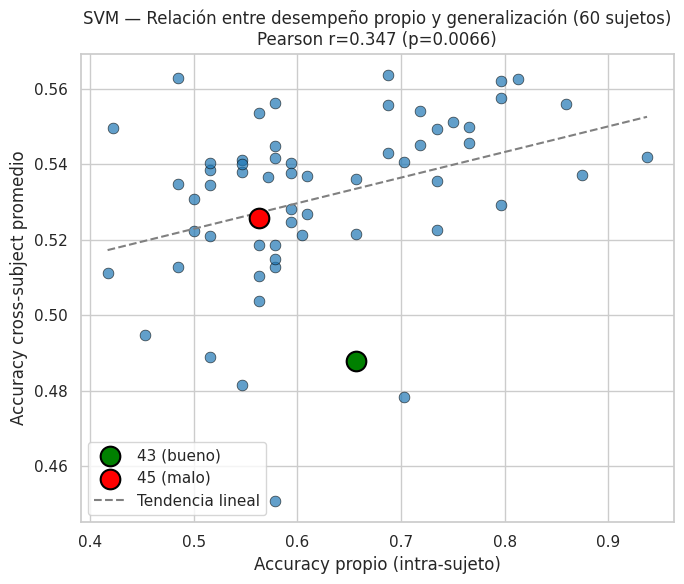

In [12]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(resumen_por_origen['accuracy_propio'], resumen_por_origen['accuracy_cross_promedio'],
           color='#1f77b4', alpha=0.7, s=60, edgecolors='black', linewidth=0.5)

# Resaltar los sujetos 43 y 45
for sid, color, label in [(43, 'green', '43 (bueno)'), (45, 'red', '45 (malo)')]:
    fila = resumen_por_origen[resumen_por_origen['sujeto_origen'] == sid]
    ax.scatter(fila['accuracy_propio'], fila['accuracy_cross_promedio'],
               color=color, s=200, zorder=5, label=label, edgecolors='black', linewidth=1.5)

# Línea de tendencia
z = np.polyfit(resumen_por_origen['accuracy_propio'], resumen_por_origen['accuracy_cross_promedio'], 1)
x_line = np.linspace(resumen_por_origen['accuracy_propio'].min(), resumen_por_origen['accuracy_propio'].max(), 100)
ax.plot(x_line, np.polyval(z, x_line), color='gray', linestyle='--', label='Tendencia lineal')

ax.set_xlabel('Accuracy propio (intra-sujeto)')
ax.set_ylabel('Accuracy cross-subject promedio')
ax.set_title('SVM — Relación entre desempeño propio y generalización (60 sujetos)\n'
             'Pearson r=0.347 (p=0.0066)')
ax.legend()
plt.tight_layout()
plt.show()

#### - HALLAZGO
la relación accuracy propio↔generalización, aunque significativa, no es determinística, y que el desempeño intra-sujeto por sí solo no garantiza nada. Esto surge a partir de la Fase 3 donde se observó que para estos sujetos en Loss function uno tuvo buen desempeño y el otro tenía un sobreajuste que el modelo generalizaba.

TODOS LOS SUJETOS

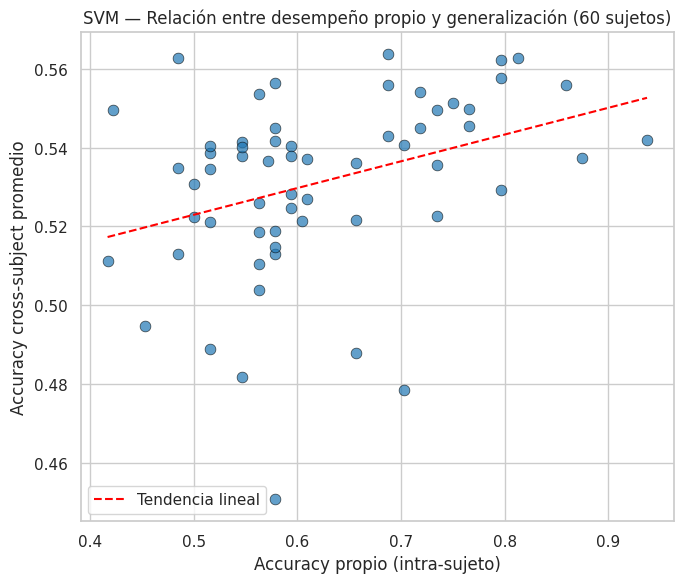

In [13]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(resumen_por_origen['accuracy_propio'], resumen_por_origen['accuracy_cross_promedio'],
           color='#1f77b4', alpha=0.7, s=60, edgecolors='black', linewidth=0.5)

z = np.polyfit(resumen_por_origen['accuracy_propio'], resumen_por_origen['accuracy_cross_promedio'], 1)
x_line = np.linspace(resumen_por_origen['accuracy_propio'].min(), resumen_por_origen['accuracy_propio'].max(), 100)
ax.plot(x_line, np.polyval(z, x_line), color='red', linestyle='--', label='Tendencia lineal')

ax.set_xlabel('Accuracy propio (intra-sujeto)')
ax.set_ylabel('Accuracy cross-subject promedio')
ax.set_title('SVM — Relación entre desempeño propio y generalización (60 sujetos)')
ax.legend()
plt.tight_layout()
plt.show()

Se ve la tendencia ascendente (línea roja) que confirma la correlación positiva: a medida que el accuracy propio aumenta (eje X), el accuracy cross-subject promedio tiende a subir también (eje Y). Pero la nube de puntos está bastante dispersa alrededor de la línea no es una relación fuerte ni ajustada, coherente con un r moderado (~0.35-0.40), no un r cercano a 1.

Se nota también que el rango de variación en Y (accuracy cross-subject) es mucho más acotado (~0.45 a 0.56) que en X (accuracy propio, ~0.40 a 0.94); es decir, sin importar cuán bien module un sujeto en su propio test, la capacidad de "enseñarle" a otros sujetos queda comprimida en un rango bastante más chico y cercano al azar. Esto refuerza la idea de que la generalización cross-subject es intrínsecamente difícil, incluso para los sujetos con mejor desempeño propio.

## Comparación Dreyer2023A vs Cho2017

In [14]:
from scipy.stats import wilcoxon

comparacion_datasets = df_cross_completo.groupby('dataset_destino').agg(
    accuracy_media=('accuracy_cross', 'mean'),
    auc_roc_media=('auc_roc_cross', 'mean'),
    recall_media=('recall_cross', 'mean')
)
print(comparacion_datasets)

acc_por_origen_dreyer = df_cross_completo[df_cross_completo['dataset_destino']=='Dreyer2023A'].groupby('sujeto_origen')['accuracy_cross'].mean()
acc_por_origen_cho = df_cross_completo[df_cross_completo['dataset_destino']=='Cho2017'].groupby('sujeto_origen')['accuracy_cross'].mean()

stat, p_value = wilcoxon(acc_por_origen_dreyer, acc_por_origen_cho)
print(f"\nWilcoxon pareado (Dreyer vs Cho2017, por sujeto origen): p={p_value:.4f}")
print(f"Media Dreyer2023A (misma DB): {acc_por_origen_dreyer.mean():.4f}")
print(f"Media Cho2017 (otra DB): {acc_por_origen_cho.mean():.4f}")

                 accuracy_media  auc_roc_media  recall_media
dataset_destino                                             
Cho2017                0.513840       0.536131      0.701035
Dreyer2023A            0.546665       0.581543      0.559135

Wilcoxon pareado (Dreyer vs Cho2017, por sujeto origen): p=0.0000
Media Dreyer2023A (misma DB): 0.5467
Media Cho2017 (otra DB): 0.5138


La comparación sistemática entre destinos confirmó una diferencia estadísticamente muy significativa (Wilcoxon pareado, p<0.0001) entre la generalización intra-dataset (Dreyer2023A, accuracy promedio=0.5467) y la generalización cross-dataset (Cho2017, accuracy promedio=0.5138). Esta caída adicional de aproximadamente 3.3 puntos porcentuales es consistente con la hipótesis planteada: las diferencias sistemáticas de equipo de adquisición y protocolo experimental entre datasets constituyen una fuente de variabilidad adicional e independiente de la variabilidad puramente inter-sujeto, degradando aún más el rendimiento de un modelo entrenado con datos de una única fuente. Adicionalmente, se observó un incremento del recall en el escenario cross-dataset (0.701 vs 0.559) acompañado de una caída en accuracy y AUC-ROC, sugiriendo que los modelos tienden a sesgar sus predicciones hacia una clase particular al enfrentar datos de un protocolo de adquisición distinto, en lugar de mantener una discriminación genuina entre ambas condiciones motoras.

## Visualizacion

/tmp/ipykernel_818/3637274663.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cross_completo, x='dataset_destino', y='accuracy_cross',


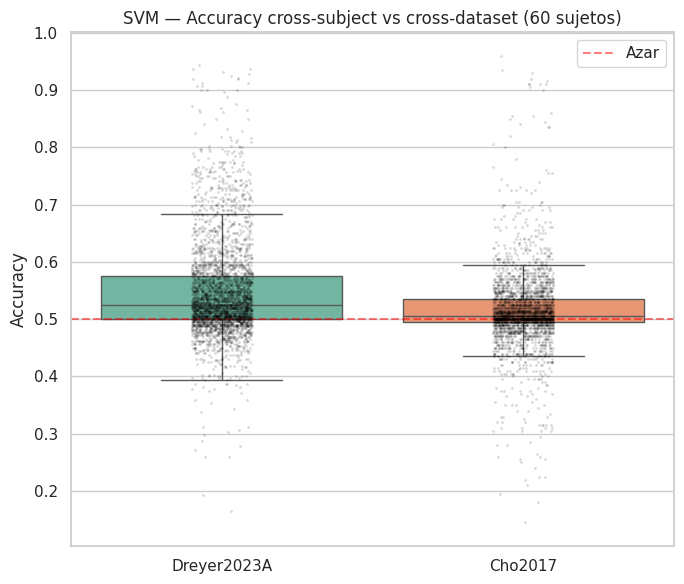

In [15]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(7, 6))
sns.boxplot(data=df_cross_completo, x='dataset_destino', y='accuracy_cross',
            palette='Set2', showfliers=False, ax=ax)
sns.stripplot(data=df_cross_completo, x='dataset_destino', y='accuracy_cross',
              color='black', alpha=0.15, jitter=True, size=2, ax=ax)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Azar')
ax.set_title('SVM — Accuracy cross-subject vs cross-dataset (60 sujetos)')
ax.set_xlabel('')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

## SVM vs EEGNet : Sujeto 43 vs 45

In [16]:
import pandas as pd

resumen_comparacion = []

# --- SVM (desde df_cross_bueno y df_cross_malo) ---
for sujeto_id, df_cross, etiqueta in [(43, df_cross_bueno, 'bueno'), (45, df_cross_malo, 'malo')]:
    for destino in ['Dreyer2023A', 'Cho2017']:
        df_dest = df_cross[df_cross['dataset_destino'] == destino]
        resumen_comparacion.append({
            'Sujeto': f'{sujeto_id} ({etiqueta})',
            'Modelo': 'SVM',
            'Destino': destino,
            'Accuracy': round(df_dest['accuracy_cross'].mean(), 4),
            'AUC-ROC': round(df_dest['auc_roc_cross'].mean(), 4)
        })

# --- EEGNet (desde df_eegnet_cross) ---
for sujeto_id, etiqueta in [(43, 'bueno'), (45, 'malo')]:
    for destino in ['Dreyer2023A', 'Cho2017']:
        df_dest = df_eegnet_cross[
            (df_eegnet_cross['sujeto_origen'] == sujeto_id) &
            (df_eegnet_cross['dataset_destino'] == destino)
        ]
        resumen_comparacion.append({
            'Sujeto': f'{sujeto_id} ({etiqueta})',
            'Modelo': 'EEGNet',
            'Destino': destino,
            'Accuracy': round(df_dest['accuracy_cross'].mean(), 4),
            'AUC-ROC': round(df_dest['auc_roc_cross'].mean(), 4)
        })

tabla_final_comparacion = pd.DataFrame(resumen_comparacion)
display(tabla_final_comparacion)

,Sujeto,Modelo,Destino,Accuracy,AUC-ROC
0,43 (bueno),SVM,Dreyer2023A,0.4935,0.4885
1,43 (bueno),SVM,Cho2017,0.4816,0.4601
2,45 (malo),SVM,Dreyer2023A,0.5475,0.5799
3,45 (malo),SVM,Cho2017,0.5014,0.5238
4,43 (bueno),EEGNet,Dreyer2023A,0.5836,0.6246
5,43 (bueno),EEGNet,Cho2017,0.5329,0.5558
6,45 (malo),EEGNet,Dreyer2023A,0.5579,0.5873
7,45 (malo),EEGNet,Cho2017,0.5239,0.5287


## Visualizacion

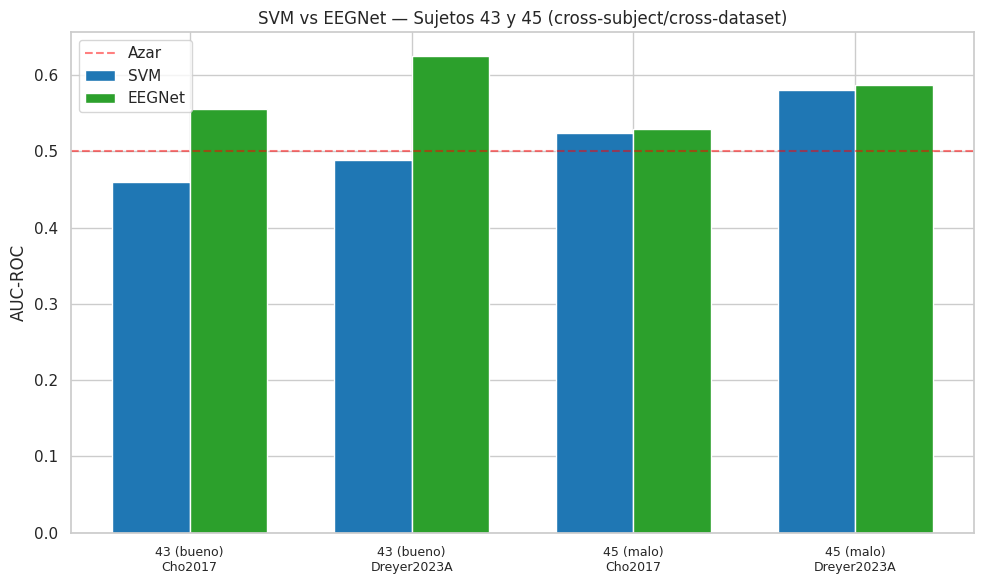

In [17]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

pivot = tabla_final_comparacion.pivot_table(index=['Sujeto', 'Destino'], columns='Modelo', values='AUC-ROC')
pivot = pivot.reset_index()
pivot['label'] = pivot['Sujeto'] + '\n' + pivot['Destino']

x = np.arange(len(pivot))
width = 0.35

ax.bar(x - width/2, pivot['SVM'], width, label='SVM', color='#1f77b4')
ax.bar(x + width/2, pivot['EEGNet'], width, label='EEGNet', color='#2ca02c')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Azar')

ax.set_xticks(x)
ax.set_xticklabels(pivot['label'], fontsize=9)
ax.set_ylabel('AUC-ROC')
ax.set_title('SVM vs EEGNet — Sujetos 43 y 45 (cross-subject/cross-dataset)')
ax.legend()
plt.tight_layout()
plt.show()

## Cruce con el filtro de BCI Illiteracy

In [ ]:
from scipy.stats import mannwhitneyu

resumen_con_aptitud = resumen_por_origen.merge(
    df_umbral_sujetos[['subject_id', 'Apto_BCI']].rename(columns={'subject_id': 'sujeto_origen'}),
    on='sujeto_origen', how='left'
)

comparacion_aptitud = resumen_con_aptitud.groupby('Apto_BCI')[['accuracy_cross_promedio', 'auc_roc_cross_promedio']].mean()
print(comparacion_aptitud)

acc_aptos = resumen_con_aptitud[resumen_con_aptitud['Apto_BCI']]['accuracy_cross_promedio']
acc_no_aptos = resumen_con_aptitud[~resumen_con_aptitud['Apto_BCI']]['accuracy_cross_promedio']

stat, p = mannwhitneyu(acc_aptos, acc_no_aptos, alternative='two-sided')
print(f"\nMann-Whitney (aptos vs no aptos como origen): p={p:.4f}")
print(f"N aptos: {len(acc_aptos)} | N no aptos: {len(acc_no_aptos)}")

          accuracy_cross_promedio  auc_roc_cross_promedio
Apto_BCI                                                 
False                    0.526617                0.553324
True                     0.536996                0.568757

Mann-Whitney (aptos vs no aptos como origen): p=0.0154
N aptos: 27 | N no aptos: 33


El análisis de generalización sobre los 60 sujetos confirmó tres hallazgos convergentes y estadísticamente consistentes entre sí: (1) existe una correlación positiva y significativa entre el desempeño intra-sujeto y la capacidad de generalización cross-subject (Pearson r=0.347, p=0.0066); (2) los sujetos clasificados como 'aptos' según el filtro de BCI Illiteracy generan modelos que generalizan significativamente mejor que los clasificados como 'no aptos' (Mann-Whitney, p=0.0154), reforzando desde una perspectiva categórica la misma relación observada de forma continua; y (3) la generalización cross-dataset (hacia Cho2017) es sistemáticamente más pobre que la generalización cross-subject dentro de la misma base de datos (Wilcoxon pareado, p<0.0001), evidenciando que las diferencias de equipo y protocolo de adquisición constituyen una fuente de degradación adicional e independiente de la variabilidad puramente individual. No obstante, la magnitud de estas relaciones es moderada en todos los casos —con AUC-ROC promedio cercano al azar (0.560) incluso en el mejor escenario—, y el análisis de casos individuales contrastantes (sujetos 43 y 45) reveló una excepción notable donde el sujeto de menor aptitud individual generalizó mejor que el de mayor aptitud, subrayando que el desempeño intra-sujeto es un predictor estadísticamente válido pero no determinístico de la calidad de generalización de un sistema BCI.